In [32]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [33]:
load_dotenv()

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [34]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explaination: str

In [35]:
def generate_joke(state: JokeState):
    prompt = f"generate a joke on the topic {state['topic']}"

    joke_response = llm.invoke(prompt).content

    return {'joke': joke_response}

In [36]:
def explain_joke(state: JokeState):
    prompt = f"write an explaination for the joke - {state['joke']}"

    explain_response = llm.invoke(prompt).content

    return {'explaination': explain_response}

In [37]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('explain_joke', explain_joke)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

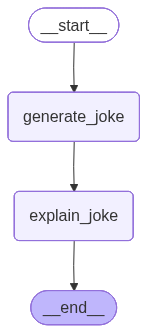

In [38]:
workflow

In [39]:
config_1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic': 'pizza'}, config=config_1)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explaination': 'A classic play on words. This joke is funny because it uses a pun to create a humorous connection between the setup and the punchline. \n\nThe joke starts by asking why the pizza is in a bad mood, which primes the listener to expect a reason related to emotions or a personal issue. However, the punchline "it was feeling a little crusty" subverts this expectation by using the word "crusty" in a double meaning.\n\nIn one sense, "crusty" can describe someone who is irritable, gruff, or ill-tempered, which fits the context of the pizza being in a bad mood. But "crusty" also literally describes the outer layer of a pizza, which is crispy and crunchy. \n\nThe humor comes from the unexpected twist on the word\'s meaning, creating a clever connection between the pizza\'s emotional state and its physical composition. The joke relies on this wordplay to create a lightheart

In [40]:
workflow.get_state(config_1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explaination': 'A classic play on words. This joke is funny because it uses a pun to create a humorous connection between the setup and the punchline. \n\nThe joke starts by asking why the pizza is in a bad mood, which primes the listener to expect a reason related to emotions or a personal issue. However, the punchline "it was feeling a little crusty" subverts this expectation by using the word "crusty" in a double meaning.\n\nIn one sense, "crusty" can describe someone who is irritable, gruff, or ill-tempered, which fits the context of the pizza being in a bad mood. But "crusty" also literally describes the outer layer of a pizza, which is crispy and crunchy. \n\nThe humor comes from the unexpected twist on the word\'s meaning, creating a clever connection between the pizza\'s emotional state and its physical composition. The joke relies on this wordplay to 

In [41]:
list(workflow.get_state_history(config_1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explaination': 'A classic play on words. This joke is funny because it uses a pun to create a humorous connection between the setup and the punchline. \n\nThe joke starts by asking why the pizza is in a bad mood, which primes the listener to expect a reason related to emotions or a personal issue. However, the punchline "it was feeling a little crusty" subverts this expectation by using the word "crusty" in a double meaning.\n\nIn one sense, "crusty" can describe someone who is irritable, gruff, or ill-tempered, which fits the context of the pizza being in a bad mood. But "crusty" also literally describes the outer layer of a pizza, which is crispy and crunchy. \n\nThe humor comes from the unexpected twist on the word\'s meaning, creating a clever connection between the pizza\'s emotional state and its physical composition. The joke relies on this wordplay to

In [42]:
config_2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic': 'pasta'}, config=config_2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a long-term relationship.',
 'explaination': 'Let\'s break down the joke and explain why it\'s funny.\n\nThe joke starts by setting up a situation where spaghetti, a type of pasta, is considering getting married. This is an unexpected and absurd scenario, as spaghetti is an inanimate object and cannot actually get married. The humor begins with the personification of the spaghetti, giving it human-like thoughts and feelings.\n\nThe punchline of the joke is that the spaghetti refuses to get married because it\'s "afraid of getting tangled up in a long-term relationship." Here\'s where the wordplay comes in. "Tangled up" has a double meaning:\n\n1. **Literal meaning**: Spaghetti is a long, thin, and flexible noodle that can easily become tangled or knotted. This is a common experience when cooking or eating spaghetti.\n2. **Figurative meaning**: In relationships, "t

In [43]:
workflow.get_state(config_2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a long-term relationship.', 'explaination': 'Let\'s break down the joke and explain why it\'s funny.\n\nThe joke starts by setting up a situation where spaghetti, a type of pasta, is considering getting married. This is an unexpected and absurd scenario, as spaghetti is an inanimate object and cannot actually get married. The humor begins with the personification of the spaghetti, giving it human-like thoughts and feelings.\n\nThe punchline of the joke is that the spaghetti refuses to get married because it\'s "afraid of getting tangled up in a long-term relationship." Here\'s where the wordplay comes in. "Tangled up" has a double meaning:\n\n1. **Literal meaning**: Spaghetti is a long, thin, and flexible noodle that can easily become tangled or knotted. This is a common experience when cooking or eating spaghetti.\n2. **Figurative meaning**: I

In [44]:
list(workflow.get_state_history(config_2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a long-term relationship.', 'explaination': 'Let\'s break down the joke and explain why it\'s funny.\n\nThe joke starts by setting up a situation where spaghetti, a type of pasta, is considering getting married. This is an unexpected and absurd scenario, as spaghetti is an inanimate object and cannot actually get married. The humor begins with the personification of the spaghetti, giving it human-like thoughts and feelings.\n\nThe punchline of the joke is that the spaghetti refuses to get married because it\'s "afraid of getting tangled up in a long-term relationship." Here\'s where the wordplay comes in. "Tangled up" has a double meaning:\n\n1. **Literal meaning**: Spaghetti is a long, thin, and flexible noodle that can easily become tangled or knotted. This is a common experience when cooking or eating spaghetti.\n2. **Figurative meaning**: 

## Time Travel

In [23]:
# get single state based on the checkpoint id
workflow.get_state(config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f16e4ae-5efc-61b1-8006-1f388988acf2'}})

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explaination': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words. The term "crusty" has a double meaning here.\n\nIn one sense, "crusty" refers to the outer layer of a pizza, which is typically crunchy and crispy. This is a literal reference to the physical properties of a pizza.\n\nHowever, "crusty" can also be used to describe someone\'s personality or mood, implying that they are irritable, grumpy, or unpleasant to be around. For example, you might say "he\'s been a bit crusty all day" to describe someone who is in a bad mood.\n\nThe joke relies on this double meaning of "crusty" to create a pun. By saying the pizza is "feeling a little crusty", the joke is making a wordplay on the pizza\'s literal crust, while also implying that the pizza is in a bad mood. It\'s a lighthearted and humorous way to describ

In [24]:
# execute the workflow again but after a certain checkpoint
workflow.invoke(None, config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f16e4ae-5efc-61b1-8006-1f388988acf2'}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explaination': 'The joke "Why was the pizza in a bad mood? Because it was feeling a little crusty" is a play on words. The term "crusty" has a double meaning here.\n\nIn one sense, "crusty" refers to the outer layer of a pizza, which is typically crunchy and crispy. This is a literal reference to the physical properties of a pizza.\n\nHowever, "crusty" can also be used to describe someone\'s personality or mood, implying that they are irritable, grumpy, or unpleasant to be around. For example, you might say "he\'s been a bit crusty all day" to describe someone who is in a bad mood.\n\nThe joke relies on this double meaning of "crusty" to create a pun. By saying the pizza is "feeling a little crusty", the joke is making a wordplay on the pizza\'s literal crust, while also implying that the pizza is in a bad mood. It\'s a lighthearted and humorous way to describe a pizza\'s emotio

In [45]:
list(workflow.get_state_history(config_1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explaination': 'A classic play on words. This joke is funny because it uses a pun to create a humorous connection between the setup and the punchline. \n\nThe joke starts by asking why the pizza is in a bad mood, which primes the listener to expect a reason related to emotions or a personal issue. However, the punchline "it was feeling a little crusty" subverts this expectation by using the word "crusty" in a double meaning.\n\nIn one sense, "crusty" can describe someone who is irritable, gruff, or ill-tempered, which fits the context of the pizza being in a bad mood. But "crusty" also literally describes the outer layer of a pizza, which is crispy and crunchy. \n\nThe humor comes from the unexpected twist on the word\'s meaning, creating a clever connection between the pizza\'s emotional state and its physical composition. The joke relies on this wordplay to

## Update State

In [ ]:
# Updating state with diff value for previous checkpoint_id
workflow.update_state(config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f16ed24-7de3-69e5-8000-baa4f9fb94ac', 'checkpoint_ns': ''}}, values={'topic': 'cold drink'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16ed4b-ec4a-655d-8001-05927fa36d4f'}}

In [ ]:
# list the history
list(workflow.get_state_history(config=config_1))

[StateSnapshot(values={'topic': 'cold drink'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16ed4b-ec4a-655d-8001-05927fa36d4f'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-23T07:25:43.787582+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f16ed24-7de3-69e5-8000-baa4f9fb94ac'}}, tasks=(PregelTask(id='4a7035fe-33d0-971d-4d1f-6249636974c0', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explaination': 'A classic play on words. This joke is funny because it uses a pun to create a humorous connection between the setup and the punchline. \n\nThe joke starts by asking why the pizza is in a bad mood, which primes the listener to expec

In [ ]:
"""
    invoke the workflow but with the old checkpoint_id to see the output 
    here it executed the workflow with that old value only and not the updated one bcoz of the old checkpoint_id
"""
workflow.invoke(None, config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f16ed24-7de3-69e5-8000-baa4f9fb94ac'}})

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'explaination': 'A classic play on words. This joke is funny because it uses a pun to create a humorous connection between the setup and the punchline. \n\nThe setup "Why was the pizza in a bad mood?" primes the listener to expect a reason related to the pizza\'s emotional state. The word "crusty" has a double meaning here:\n\n1. In baking, the crust is the outer, harder layer of a bread or pastry, such as a pizza. So, "crusty" can literally describe the texture of a pizza\'s crust.\n2. In everyday language, "crusty" can also mean being irritable, gruff, or having a bad temper.\n\nThe punchline "Because it was feeling a little crusty" exploits this dual meaning, creating a wordplay that connects the pizza\'s literal crust to its metaphorical emotional state. The joke relies on this clever use of language to create a unexpected and amusing connection, making it a lighthearted and 

In [ ]:
# list the history
list(workflow.get_state_history(config=config_1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'explaination': 'A classic play on words. This joke is funny because it uses a pun to create a humorous connection between the setup and the punchline. \n\nThe setup "Why was the pizza in a bad mood?" primes the listener to expect a reason related to the pizza\'s emotional state. The word "crusty" has a double meaning here:\n\n1. In baking, the crust is the outer, harder layer of a bread or pastry, such as a pizza. So, "crusty" can literally describe the texture of a pizza\'s crust.\n2. In everyday language, "crusty" can also mean being irritable, gruff, or having a bad temper.\n\nThe punchline "Because it was feeling a little crusty" exploits this dual meaning, creating a wordplay that connects the pizza\'s literal crust to its metaphorical emotional state. The joke relies on this clever use of language to create a unexpected and amusing connection, making it

In [ ]:
# Now used the updated checkpoint_id which was generted while updating the state
workflow.invoke(None, config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f16ed4b-ec4a-655d-8001-05927fa36d4f'}})

{'topic': 'cold drink',
 'joke': 'Why did the cold drink go to therapy?\n\nBecause it was feeling a little "flat" and wanted to "chill" out its problems.',
 'explaination': 'A refreshing joke. Let\'s break it down:\n\nThe joke is a play on words, using the multiple meanings of "flat" and "chill" to create a pun. \n\n1. "Flat" has a double meaning here:\n   - In the context of drinks, a "flat" drink is one that has lost its carbonation, making it less refreshing and less fizzy. \n   - Emotionally, "feeling flat" means feeling unenthusiastic, depressed, or lacking energy.\n\n2. "Chill" also has a double meaning:\n   - "Chill out" is an idiomatic expression that means to relax, calm down, or take it easy.\n   - A cold drink is typically served "chilled," meaning it\'s been cooled to a low temperature.\n\nThe joke sets up the scenario that the cold drink is going to therapy, implying that it\'s experiencing some emotional distress. The punchline "it was feeling a little \'flat\' and wanted

In [ ]:
# list the history
list(workflow.get_state_history(config=config_1))

[StateSnapshot(values={'topic': 'cold drink', 'joke': 'Why did the cold drink go to therapy?\n\nBecause it was feeling a little "flat" and wanted to "chill" out its problems.', 'explaination': 'A refreshing joke. Let\'s break it down:\n\nThe joke is a play on words, using the multiple meanings of "flat" and "chill" to create a pun. \n\n1. "Flat" has a double meaning here:\n   - In the context of drinks, a "flat" drink is one that has lost its carbonation, making it less refreshing and less fizzy. \n   - Emotionally, "feeling flat" means feeling unenthusiastic, depressed, or lacking energy.\n\n2. "Chill" also has a double meaning:\n   - "Chill out" is an idiomatic expression that means to relax, calm down, or take it easy.\n   - A cold drink is typically served "chilled," meaning it\'s been cooled to a low temperature.\n\nThe joke sets up the scenario that the cold drink is going to therapy, implying that it\'s experiencing some emotional distress. The punchline "it was feeling a little